In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Sample - Superstore.csv" , encoding ='cp1252' )

In [7]:
df.head()
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [38]:
monthly_sales = df.groupby(['Order Date'])['Sales'].sum()
print(monthly_sales)

df['Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
print(monthly_sales)


Order Date
1/1/2017     1481.8280
1/10/2014      54.8300
1/10/2015    1018.1040
1/10/2016     174.7500
1/11/2014       9.9400
               ...    
9/8/2016     4493.9836
9/8/2017     2184.3270
9/9/2014     4043.5880
9/9/2016       84.9920
9/9/2017     4356.0610
Name: Sales, Length: 1237, dtype: float64
    Year  Month        Sales
0   2014      1   14236.8950
1   2014      2    4519.8920
2   2014      3   55691.0090
3   2014      4   28295.3450
4   2014      5   23648.2870
5   2014      6   34595.1276
6   2014      7   33946.3930
7   2014      8   27909.4685
8   2014      9   81777.3508
9   2014     10   31453.3930
10  2014     11   78628.7167
11  2014     12   69545.6205
12  2015      1   18174.0756
13  2015      2   11951.4110
14  2015      3   38726.2520
15  2015      4   34195.2085
16  2015      5   30131.6865
17  2015      6   24797.2920
18  2015      7   28765.3250
19  2015      8   36898.3322
20  2015      9   64595.9180
21  2015     10   31404.9235
22  2015     11   75972.563

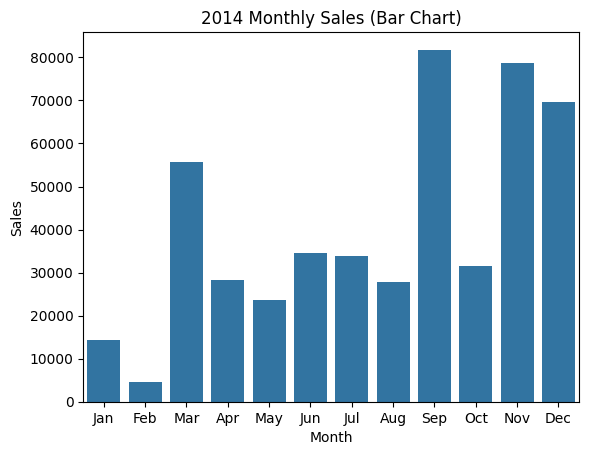

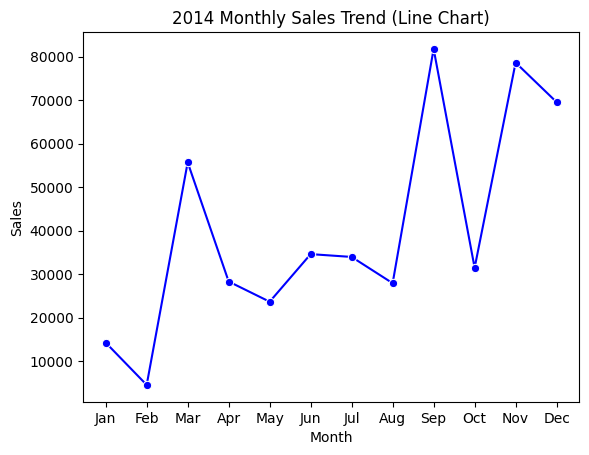

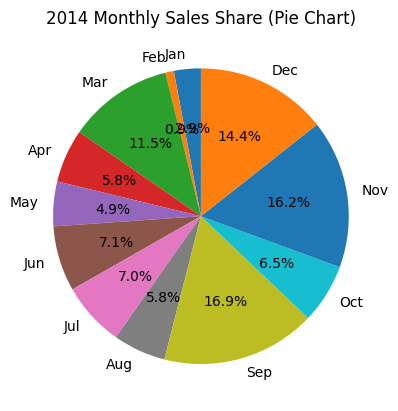

In [111]:
df_2014 = df[df['Year'] == 2014]
monthly_sales_2014 = df_2014.groupby(df_2014['Date'].dt.month)['Sales'].sum().reset_index()
monthly_sales_2014.columns = ['Month_Num', 'Sales']

monthly_sales_2014 = monthly_sales_2014.sort_values('Month_Num')
monthly_sales_2014['Month'] = pd.to_datetime(monthly_sales_2014['Month_Num'], format='%m').dt.strftime('%b')

sns.barplot(data=monthly_sales_2014, x='Month', y='Sales')
plt.title('2014 Monthly Sales (Bar Chart)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

sns.lineplot(data=monthly_sales_2014, x='Month', y='Sales', marker='o', color='blue')
plt.title('2014 Monthly Sales Trend (Line Chart)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

plt.pie(monthly_sales_2014['Sales'], labels=monthly_sales_2014['Month'], autopct='%1.1f%%', startangle=90)
plt.title('2014 Monthly Sales Share (Pie Chart)')
plt.show()

Winner (Shows trend best): The line Chart. It connects data points chronologically, making changes in direction, slope, and pattern instantly recognizable.Loser (Hides the trend): The Pie Chart. It strips away time and order to show part-to-whole slices, making it impossible to follow a timeline.

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64


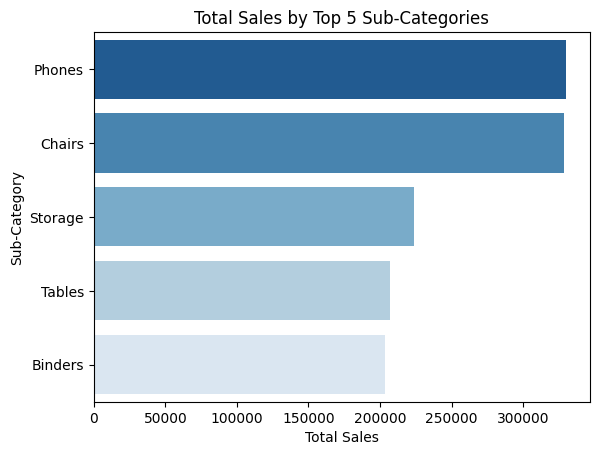

In [20]:
#task 2
top_5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)
print(top_5)

sns.barplot(x=top_5.values, y=top_5.index, hue=top_5.index, palette="Blues_r")
plt.title("Total Sales by Top 5 Sub-Categories")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()

Optimal Choice: Horizontal Bar Chart. It lets viewers easily scan, rank, and compare discrete magnitudes from longest to shortest bar
A bar chart fits because the data consists of nominal categories
a pie chart would underperform or mislead because human eyes struggle to compare subtle slice areas or irregular angles cleanly when ranking items close in value.

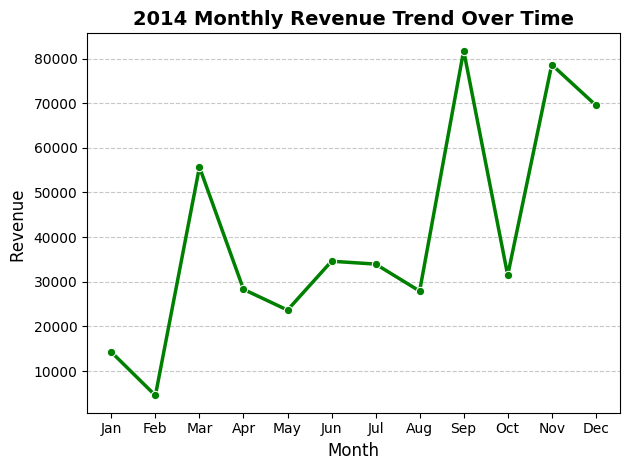

In [59]:
sns.lineplot(data=monthly_sales_2014, x='Month', y='Sales', marker='o', color='green', linewidth=2.5)
plt.title('2014 Monthly Revenue Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Line Chart. Connecting continuous temporal points with an index or slope directly matches how humans intuitively process chronology and velocity.
A line chart perfectly highlights continuous movement; a pie chart is a weak choice that completely destroys chronological order by treating months as independent, unsequenced slices of a whole

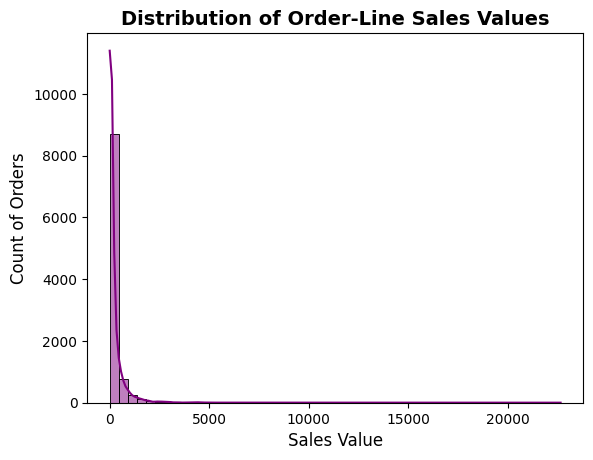

In [52]:
sns.histplot(data=df, x='Sales', kde=True, color='purple', bins=50)
plt.title('Distribution of Order-Line Sales Values', fontsize=14, fontweight='bold')
plt.xlabel('Sales Value', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.show()

Histogram. It breaks thousands of raw data records down into distinct continuous numerical ranges (bins) to reveal structural skewness and density peaks.
A histogram captures the macro data shape; a standard bar chart would catastrophically fail, creating thousands of messy individual columns that clutter the canvas and mask the overall shape of the dataset.

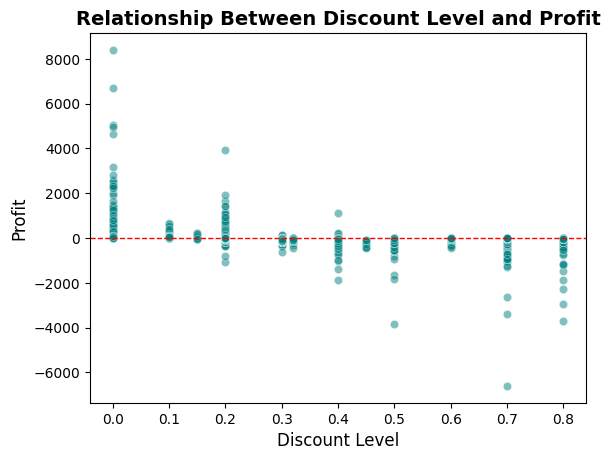

In [58]:
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Relationship Between Discount Level and Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.show()

Scatter Plot. It preserves the raw data granularity by rendering every individual transaction line as a distinct coordinate point to map absolute, unaggregated correlations.
A scatter plot maps multi-dimensional variance honestly; an aggregated bar chart would deeply mislead by wiping out thousands of crucial outliers and flattening complex critical thresholds into deceptively simple, smoothed averages.

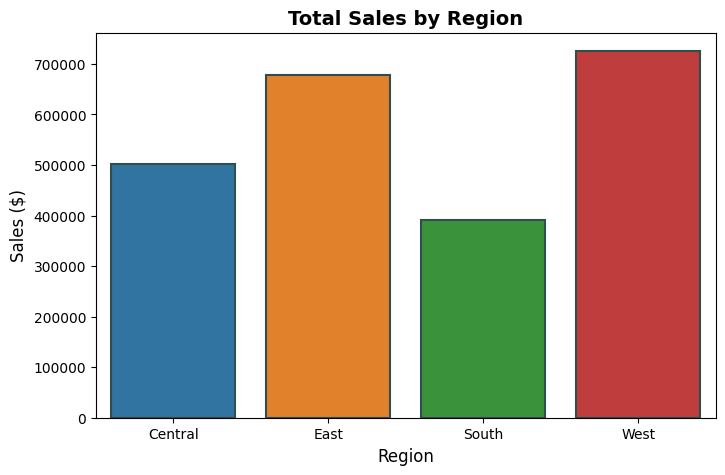

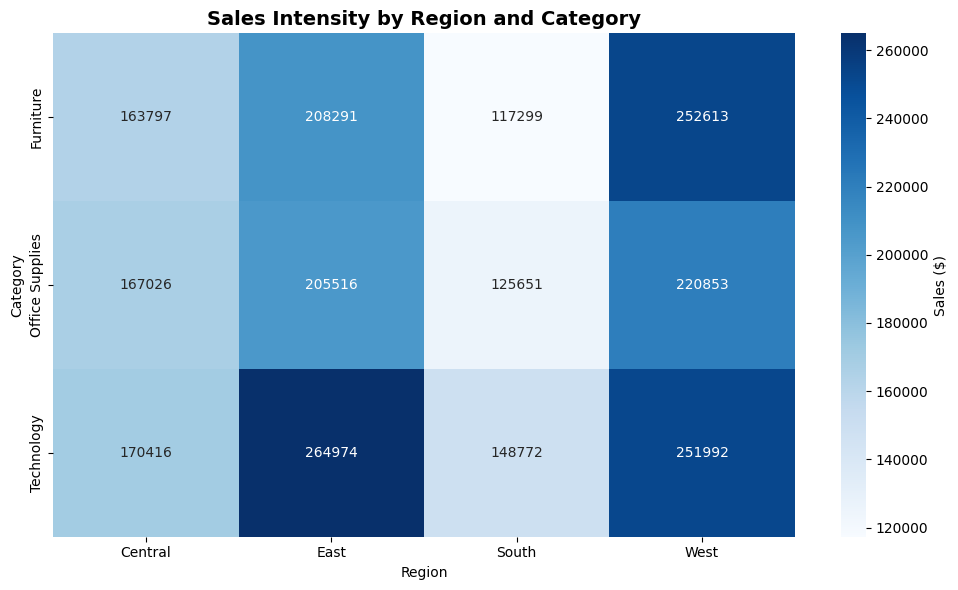

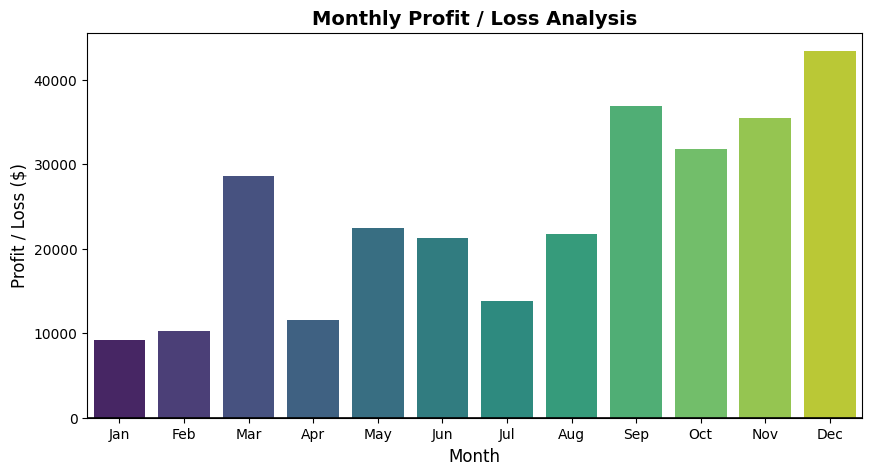

In [81]:
#task 3
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='Region', y='Sales',hue='Region', palette='tab10',  edgecolor='#2F4F4F', linewidth=1.5)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.show()

region_category_sales = df.groupby(['Category', 'Region'])['Sales'].sum().reset_index()
heatmap_data = region_category_sales.pivot(index='Category', columns='Region', values='Sales')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='Blues', cbar_kws={'label': 'Sales ($)'})
plt.title('Sales Intensity by Region and Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


df['Date'] = pd.to_datetime(df['Order Date'])
df['Month_Num'] = df['Date'].dt.month
monthly_profit = df.groupby('Month_Num')['Profit'].sum().reset_index()
monthly_profit = monthly_profit.sort_values('Month_Num')
monthly_profit['Month'] = pd.to_datetime(monthly_profit['Month_Num'], format='%m').dt.strftime('%b')
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_profit, x='Month', y='Profit', hue='Month', palette='viridis')
plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
plt.title('Monthly Profit / Loss Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Profit / Loss ($)', fontsize=12)

plt.show()


In [83]:
#task 4
def contrast(c1, c2=(255, 255, 255)):
    lum = []
    for c in [c1, c2]:
        rgb = [x/255.0 for x in c]
        rgb = [x / 12.92 if x <= 0.03928 else ((x + 0.055) / 1.055) ** 2.4 for x in rgb]
        lum.append(0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2])
    return (max(lum) + 0.05) / (min(lum) + 0.05)

set2_colors = [tuple(int(x*255) for x in c[:3]) for c in sns.color_palette('tab10')]
print("\n--- Set2 Palette (Region Chart) ---")
for i, col in enumerate(set2_colors):
    ratio = contrast(col)
    status = "PASS" if ratio >= 4.5 else "FAIL "
    print(f"Color {i+1} {col}: Ratio {ratio:.2f}:1 -> {status}")

blues_colors = [tuple(int(x*255) for x in c[:3]) for c in sns.color_palette('Blues', 5)]
print("\n--- Blues Palette (Heatmap Chart) ---")
print(f"Lightest Blue {blues_colors[0]}: Ratio {contrast(blues_colors[0]):.2f}:1 -> {'PASS' if contrast(blues_colors[0]) >= 4.5 else 'FAIL '}")
print(f"Darkest Blue {blues_colors[-1]}: Ratio {contrast(blues_colors[-1]):.2f}:1 -> {'PASS' if contrast(blues_colors[-1]) >= 4.5 else 'FAIL '}")

viridis_colors = [tuple(int(x*255) for x in c[:3]) for c in sns.color_palette('viridis', 12)]
print("\n--- Viridis Palette (Monthly Profit Chart)")
for i, col in enumerate(viridis_colors):
    ratio = contrast(col)
    status = "PASS" if ratio >= 4.5 else "FAIL "
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    print(f"{months[i]} Color {col}: Ratio {ratio:.2f}:1 -> {status}")




--- Set2 Palette (Region Chart) ---
Color 1 (31, 119, 180): Ratio 4.82:1 -> PASS
Color 2 (255, 127, 14): Ratio 2.53:1 -> FAIL 
Color 3 (44, 160, 44): Ratio 3.40:1 -> FAIL 
Color 4 (214, 39, 40): Ratio 5.02:1 -> PASS
Color 5 (148, 103, 189): Ratio 4.26:1 -> FAIL 
Color 6 (140, 86, 75): Ratio 5.92:1 -> PASS
Color 7 (227, 119, 194): Ratio 2.73:1 -> FAIL 
Color 8 (127, 127, 127): Ratio 4.00:1 -> FAIL 
Color 9 (188, 189, 34): Ratio 2.01:1 -> FAIL 
Color 10 (23, 190, 207): Ratio 2.26:1 -> FAIL 

--- Blues Palette (Heatmap Chart) ---
Lightest Blue (214, 229, 244): Ratio 1.28:1 -> FAIL 
Darkest Blue (15, 91, 163): Ratio 6.90:1 -> PASS

--- Viridis Palette (Monthly Profit Chart)
Jan Color (72, 28, 110): Ratio 12.60:1 -> PASS
Feb Color (69, 53, 128): Ratio 10.13:1 -> PASS
Mar Color (61, 76, 137): Ratio 8.10:1 -> PASS
Apr Color (51, 96, 141): Ratio 6.57:1 -> PASS
May Color (43, 116, 142): Ratio 5.26:1 -> PASS
Jun Color (35, 135, 141): Ratio 4.27:1 -> FAIL 
Jul Color (30, 153, 138): Ratio 3.51:1 

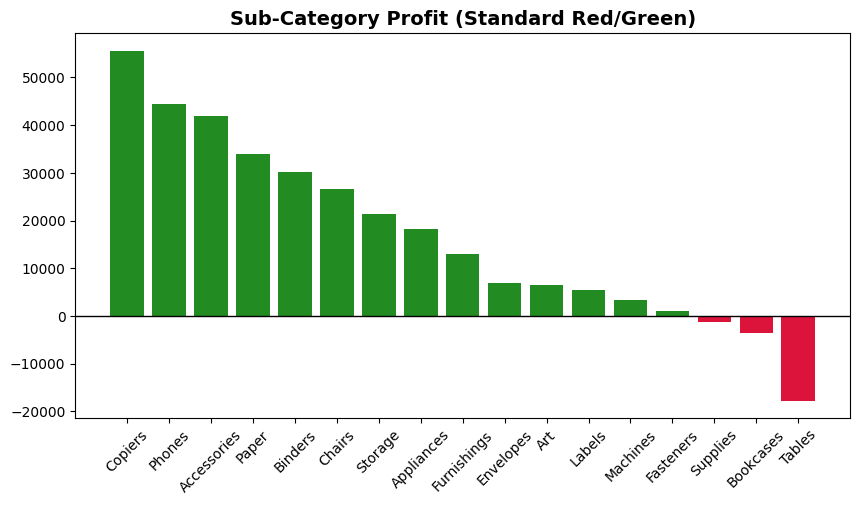

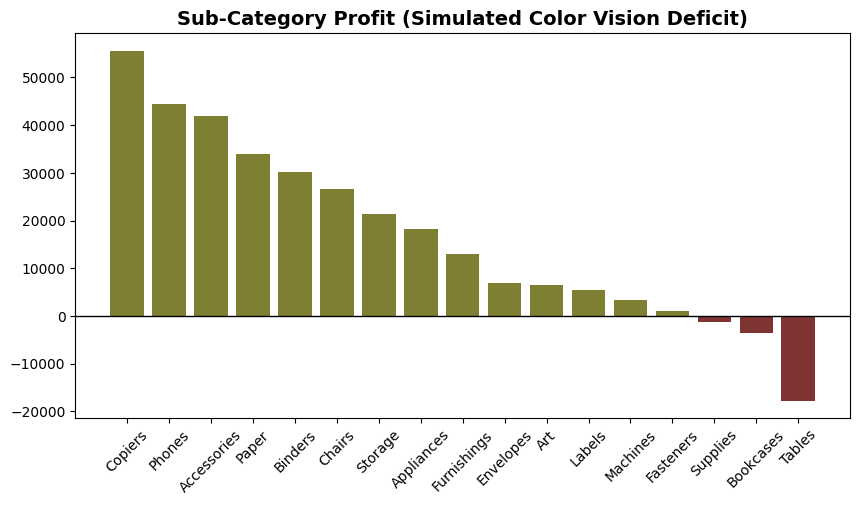

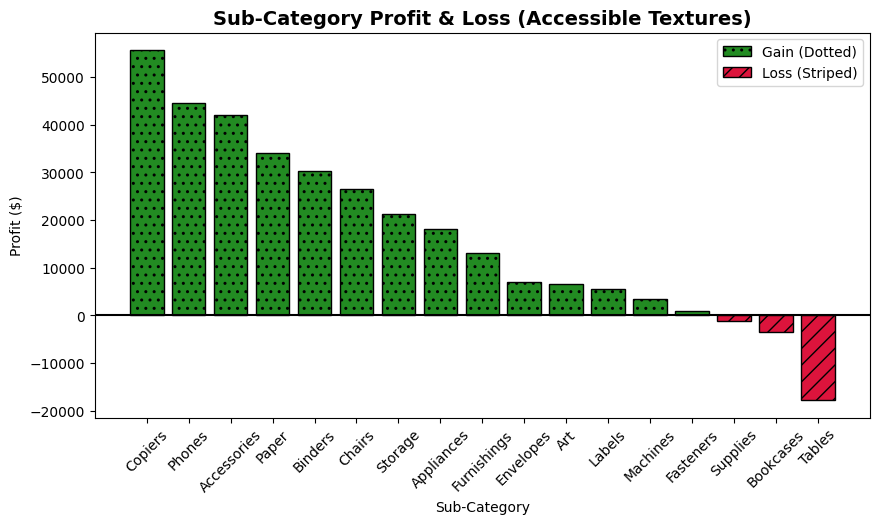

In [87]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
subcat_profit = subcat_profit.sort_values('Profit', ascending=False)
rg_colors = ['#228B22' if x >= 0 else '#DC143C' for x in subcat_profit['Profit']]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=rg_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Sub-Category Profit (Standard Red/Green)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

sim_colors = ['#7F7F33' if x >= 0 else '#7F3333' for x in subcat_profit['Profit']]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=sim_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Sub-Category Profit (Simulated Color Vision Deficit)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()



fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=rg_colors, edgecolor='black', linewidth=1)
for bar, val in zip(bars, subcat_profit['Profit']):
    if val < 0:
        bar.set_hatch('//')
    else:
        bar.set_hatch('..')
plt.axhline(0, color='black', linewidth=1.5)
plt.title('Sub-Category Profit & Loss (Accessible Textures)', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#228B22', edgecolor='black', hatch='..', label='Gain (Dotted)'),
    Patch(facecolor='#DC143C', edgecolor='black', hatch='//', label='Loss (Striped)')
]
ax.legend(handles=legend_elements, loc='upper right')
plt.show()


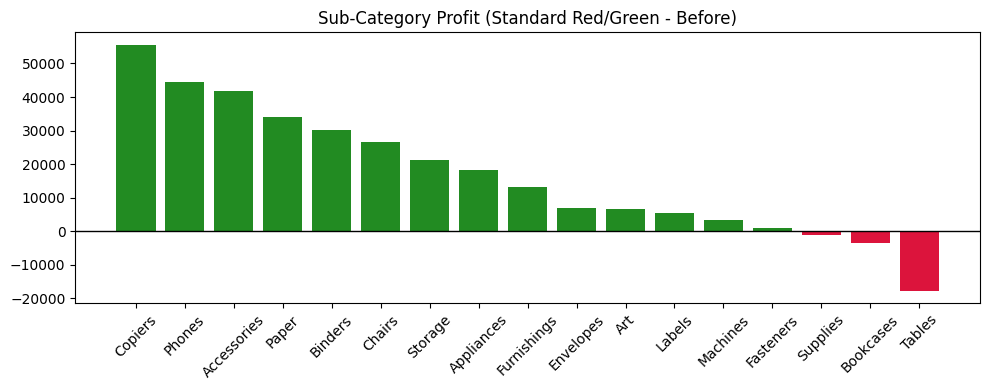

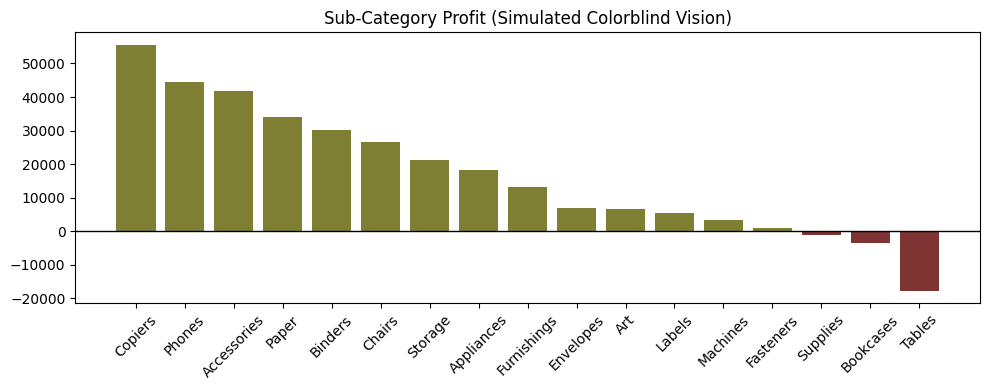

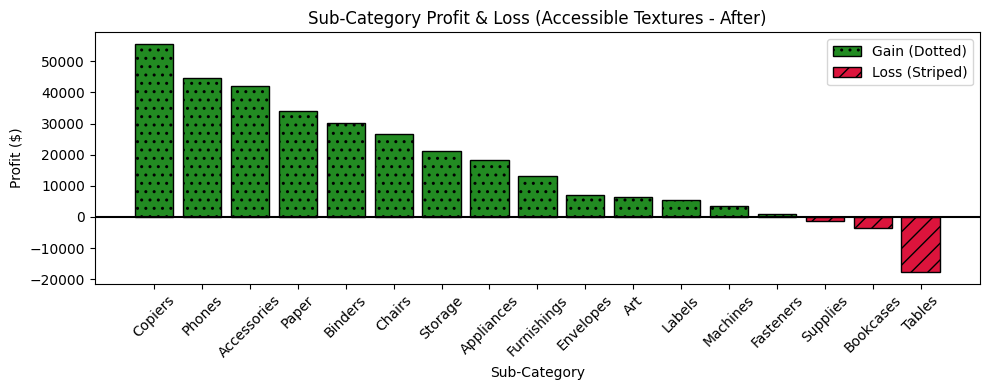

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

subcat_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
subcat_profit = subcat_profit.sort_values('Profit', ascending=False)

rg_colors = ['#228B22' if x >= 0 else '#DC143C' for x in subcat_profit['Profit']]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=rg_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Sub-Category Profit (Standard Red/Green - Before)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sim_colors = ['#7F7F33' if x >= 0 else '#7F3333' for x in subcat_profit['Profit']]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=sim_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Sub-Category Profit (Simulated Colorblind Vision)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=rg_colors, edgecolor='black', linewidth=1)

for bar, val in zip(bars, subcat_profit['Profit']):
    if val < 0:
        bar.set_hatch('//')
    else:
        bar.set_hatch('..')

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Sub-Category Profit & Loss (Accessible Textures - After)')
plt.xlabel('Sub-Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#228B22', edgecolor='black', hatch='..', label='Gain (Dotted)'),
    Patch(facecolor='#DC143C', edgecolor='black', hatch='//', label='Loss (Striped)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


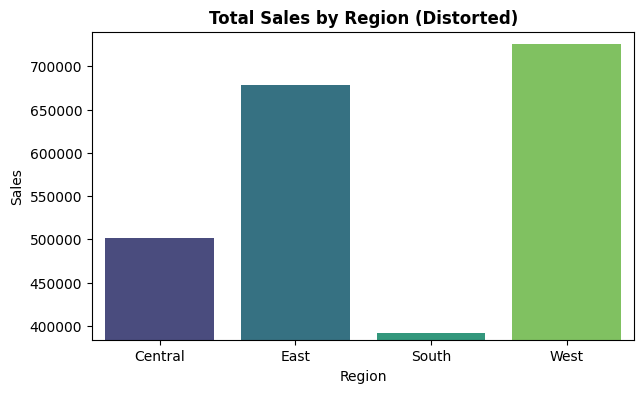

In [103]:
#task 5
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=region_sales, x='Region', y='Sales', hue='Region', palette='viridis', legend=False)
min_sales = region_sales['Sales'].min()
max_sales = region_sales['Sales'].max()
plt.ylim(min_sales * 0.98, max_sales * 1.02)
plt.title('Total Sales by Region (Distorted)', fontsize=12, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()


Distortion Mechanism: Truncated Y-Axis — Slicing the numeric baseline from zero artificially inflates and exaggerates minor sales variations between regions

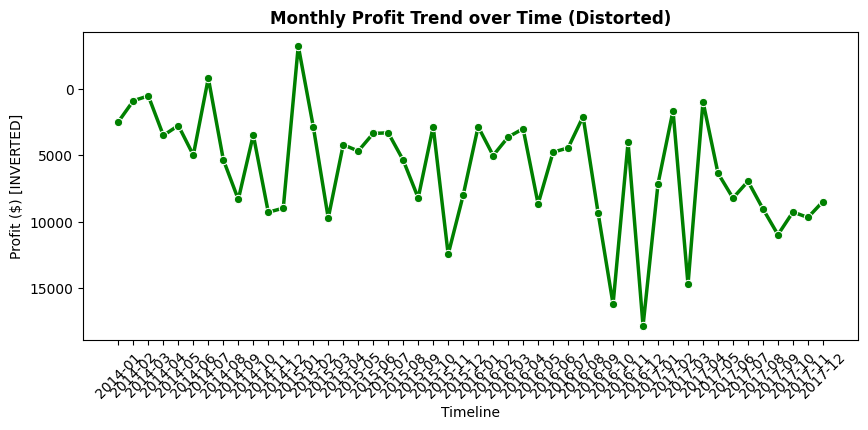

In [104]:
df['Date'] = pd.to_datetime(df['Order Date'])
monthly_profit = df.groupby(df['Date'].dt.to_period('M'))['Profit'].sum().reset_index()
monthly_profit['Month_Str'] = monthly_profit['Date'].astype(str)
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_profit, x='Month_Str', y='Profit', marker='o', color='green', linewidth=2.5)
plt.gca().invert_yaxis()
plt.title('Monthly Profit Trend over Time (Distorted)', fontsize=12, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Profit ($) [INVERTED]')
plt.xticks(rotation=45)
plt.show()


Distortion Mechanism: Inverted Y-Axis — Reversing the scale vertical orientation deceptively transforms downward financial losses into ascending peaks

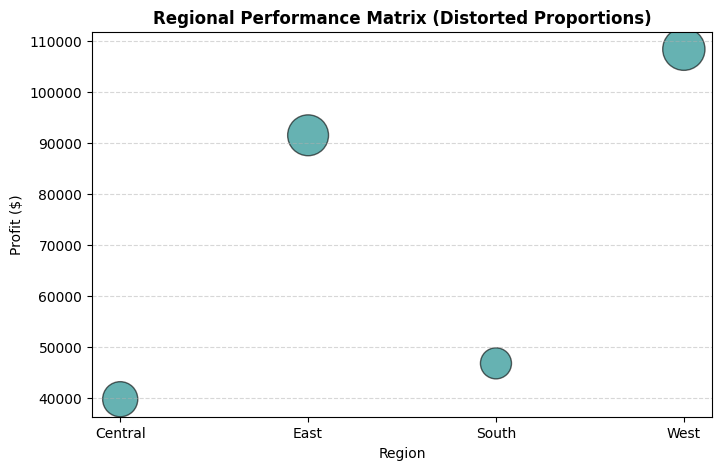

In [95]:
bubble_data = df.groupby('Region').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()

plt.figure(figsize=(8, 5))
invalid_sizes = bubble_data['Sales'] / bubble_data['Sales'].min() * 500
plt.scatter(x=bubble_data['Region'], y=bubble_data['Profit'], s=invalid_sizes, alpha=0.6, color='teal', edgecolors='black')
plt.title('Regional Performance Matrix (Distorted Proportions)', fontsize=12, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Distortion Mechanism: Radius Sizing Inflation — Scaling indicators linearly by radius instead of visual area exponentially exaggerates high performance metrics

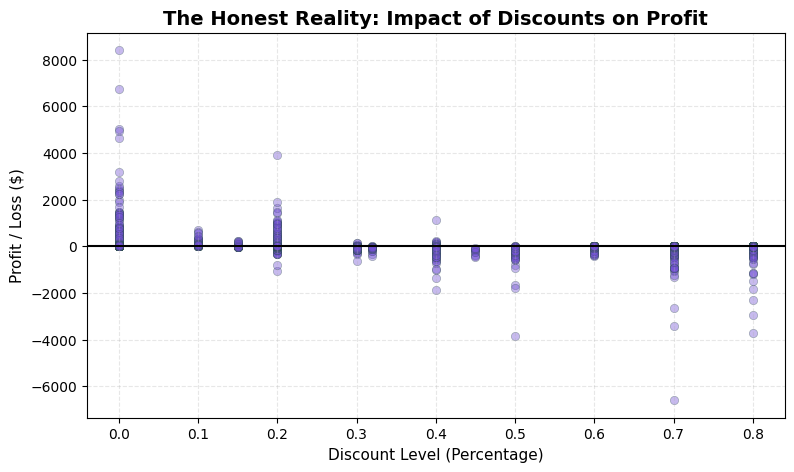

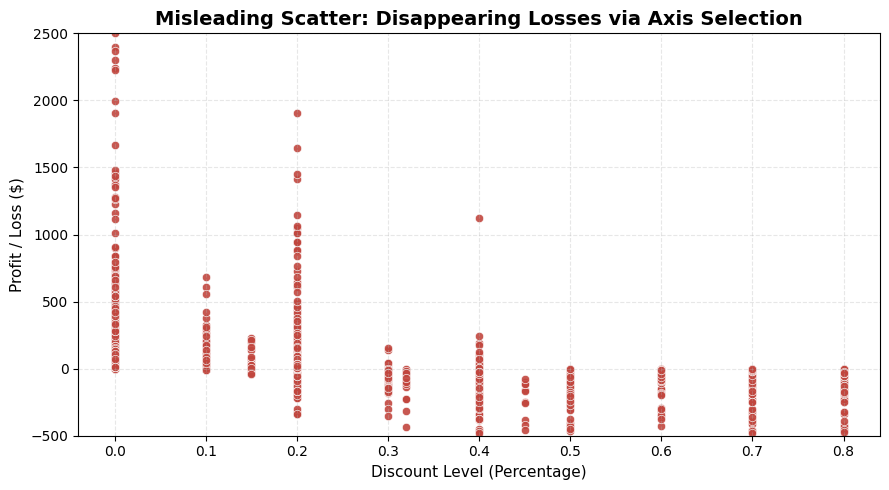

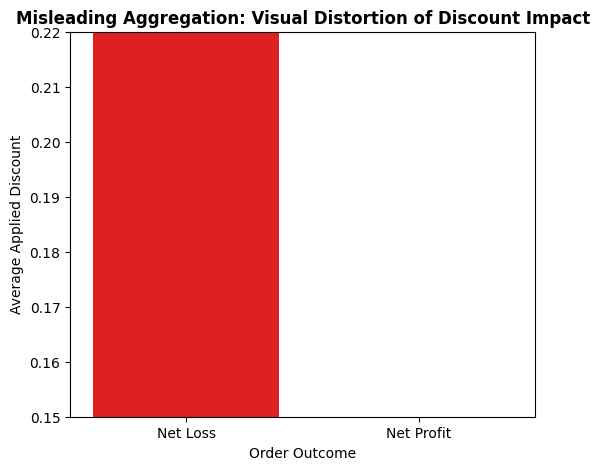

In [110]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='#7453d5', edgecolor='#2F4F4F', linewidth=0.5)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)
plt.title('The Honest Reality: Impact of Discounts on Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Level (Percentage)', fontsize=11)
plt.ylabel('Profit / Loss ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.9, color='#c1463e')
plt.ylim(-500, 2500)
plt.title('Misleading Scatter: Disappearing Losses via Axis Selection', fontsize=14, fontweight='bold')
plt.xlabel('Discount Level (Percentage)', fontsize=11)
plt.ylabel('Profit / Loss ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


df['Performance'] = ['Net Loss' if x < 0 else 'Net Profit' for x in df['Profit']]
deceptive_data = df.groupby('Performance')['Discount'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(data=deceptive_data, x='Performance', y='Discount', color='red', legend=False)
plt.ylim(0.15, 0.22)
plt.title('Misleading Aggregation: Visual Distortion of Discount Impact', fontsize=12, fontweight='bold')
plt.xlabel('Order Outcome')
plt.ylabel('Average Applied Discount')
plt.show()


The text contrasts honest and misleading data visualizations by analyzing chart types, color palettes, and WCAG accessibility standards. An honest scatter plot preserves raw data granularity and uses neutral styling and compliant contrast ratios, whereas a misleading bar chart obscures critical thresholds and manipulates visual perception. You can review the visualization comparison guide for further details.